In [1]:
import operator
from dataclasses import dataclass
from typing import Annotated, ClassVar, Literal, TypedDict, cast

from IPython.display import Image, display
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.state import CompiledStateGraph
from langgraph.types import Command, interrupt


In [2]:
class State(TypedDict):
    nlist: Annotated[list[str], operator.add]


Destination = Literal["a", "b", "c", "__end__"]
Selection = Literal["b", "c", "q"]


class DefaultRouteResume(TypedDict):
    action: Literal["route"]


class RouteContinueResume(TypedDict):
    action: Literal["route-continue"]
    destination: str


ResumeChoice = DefaultRouteResume | RouteContinueResume


In [ ]:
class InterruptingRouter:
    routes: ClassVar[dict[Selection, Destination]] = {"b": "b", "c": "c", "q": END}

    def route_to(self, selection: Selection) -> Command[Destination]:
        destination = self.routes[selection]
        return Command(update=State(nlist=[selection]), goto=destination)

    def interrupt_message(self, selection: str) -> str:
        return (
            f"Unknown route {selection!r}. "
            "Use route() to go to 'b' or route_continue('b'|'c'|'q') "
            "to choose a destination."
        )

    def __call__(self, state: State) -> Command[Destination]:
        print("Entered router node")
        selection = state["nlist"][-1].lower()

        if selection in self.routes:
            return self.route_to(cast(Selection, selection))

        choice = cast(ResumeChoice, interrupt(self.interrupt_message(selection)))
        print(f"Resumed with choice {choice!r}")

        if choice["action"] == "route":
            return self.route_to("b")

        destination = choice["destination"].lower()
        if destination in self.routes:
            return self.route_to(cast(Selection, destination))

        #if route still isn't found in route-continue!
        return Command(update=State(nlist=[destination]), goto="a")


In [4]:
class AppendingNode:
    def __init__(self, node_name: str) -> None:
        self.node_name = node_name

    def __call__(self, state: State) -> State:
        appended_string = self.node_name.lower()
        return State(nlist=[appended_string])


class NodeFactory:
    @staticmethod
    def create_node(node_name: str) -> AppendingNode:
        return AppendingNode(node_name)


In [5]:
memory = InMemorySaver()
builder = StateGraph(State)
factory = NodeFactory()
builder.add_node("a", InterruptingRouter())
builder.add_node("b", factory.create_node("B"))
builder.add_node("c", factory.create_node("C"))
builder.add_edge(START, "a")
builder.add_edge("b", END)
builder.add_edge("c", END)
graph = builder.compile(checkpointer=memory)


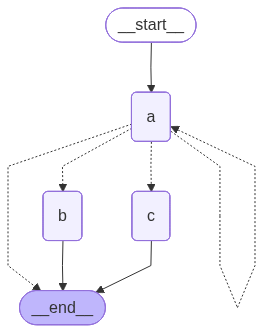

In [6]:
display(Image(graph.get_graph().draw_mermaid_png()))


In [7]:
@dataclass(frozen=True)
class ResumableSession:
    graph: CompiledStateGraph
    thread_id: str

    @property
    def config(self) -> RunnableConfig:
        return {"configurable": {"thread_id": self.thread_id}}

    def start(self, user_input: str) -> State:
        result = self.graph.invoke(State(nlist=[user_input]), self.config)
        return cast(State, result)

    def _resume(self, choice: ResumeChoice) -> State:
        result = self.graph.invoke(Command(resume=choice), self.config)
        return cast(State, result)

    def route(self) -> State:
        return self._resume(DefaultRouteResume(action="route"))

    def route_continue(self, destination: str) -> State:
        choice = RouteContinueResume(action="route-continue", destination=destination)
        return self._resume(choice)


In [8]:
direct_session = ResumableSession(graph, thread_id="direct-route")
direct_result = direct_session.start("c")
direct_result


Entered router node


{'nlist': ['c', 'c', 'c']}

In [9]:
session = ResumableSession(graph, thread_id="interrupt-demo")
interrupted_result = session.start("surprise")
interrupted_result


Entered router node


{'nlist': ['surprise'],
 '__interrupt__': [Interrupt(value="Unknown route 'surprise'. Use route() to go to 'b' or route_continue('b'|'c'|'q') to choose a destination.", id='aacd4d2b80f10506cd65a786aedf636c')]}

In [10]:
routed_result = session.route()
routed_result


Entered router node
Resumed with choice {'action': 'route'}


{'nlist': ['surprise', 'b', 'b']}

In [11]:
route_continue_session = ResumableSession(graph, thread_id="route-continue-demo")
route_continue_session.start("surprise")
route_continue_session.route_continue("c")


Entered router node
Entered router node
Resumed with choice {'action': 'route-continue', 'destination': 'c'}


{'nlist': ['surprise', 'c', 'c']}

In [12]:
route_continue_fail_session = ResumableSession(graph, thread_id="route-continue-fail")
route_continue_fail_session.start("surprise")
route_continue_fail_session.route_continue("next")


Entered router node
Entered router node
Resumed with choice {'action': 'route-continue', 'destination': 'next'}
Entered router node


{'nlist': ['surprise', 'next'],
 '__interrupt__': [Interrupt(value="Unknown route 'next'. Use route() to go to 'b' or route_continue('b'|'c'|'q') to choose a destination.", id='a039b70a8b77d65cfed195785ad60814')]}